In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from astropy.coordinates import get_sun
from astropy.time import Time

from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR,
    SCATTER_S_FINE,
)

def _ha_fmt(deg, pos=None):
    """Format decimal degrees as LaTeX $±HH^h MM^m$ (hour angle, no seconds)."""
    sign = '-' if deg < 0 else '+'
    h_abs = abs(deg) / 15.0
    hh = int(h_abs)
    mm = round((h_abs - hh) * 60)
    if mm == 60:
        hh += 1; mm = 0
    return rf'${sign}{hh}^h\,{mm:02d}^m$'

HA_FMT = mticker.FuncFormatter(_ha_fmt)

## Dataset 1 — Sun calibration sessions 1 & 2 (`sun_calibration_1`, `sun_calibration_2`)

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
PLOT_BAND_GHZ = (9.9, 10.0)

DATA_DIRS = [
    Path('../../data/lab03/sun_calibration_1'),   # Session 1: 15:04–15:21 UTC
    Path('../../data/lab03/sun_calibration_2'),   # Session 2: 16:01–16:27 UTC
]
SESSION_LABELS = [
    'Session 1  (15:04 UTC,  alt 42--44 deg)',
    'Session 2  (16:01 UTC,  alt 31--36 deg)',
]
SESSION_COLORS = ['C0', 'C1']

paths_all  = [sorted(d.glob('*.npz')) for d in DATA_DIRS]
files_all  = [[np.load(p) for p in ps] for ps in paths_all]

f0        = files_all[0][0]
F_S_HZ    = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ  = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH      = int(f0['corr'].shape[0])
N_FFT     = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ     = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

for i, (d, fs) in enumerate(zip(DATA_DIRS, files_all)):
    print(f'Session {i+1}: {len(fs)} captures  |  {d.name}')
print(f'Freq axis: {F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  {DF_HZ/1e3:.1f} kHz/ch')

# ── Mask ──────────────────────────────────────────────────────────────────
BAD_CHANNELS = [0, 256, 512, 768]   # DC/LO leak + FPGA harmonics (N_FFT/8)

amp_per_session = []
for fs in files_all:
    a = np.array([np.abs(f['corr']) for f in fs]).astype(float)
    a[:, BAD_CHANNELS] = np.nan
    amp_per_session.append(a)

# ── Normalise (global across both sessions) ───────────────────────────────
all_amp  = np.concatenate(amp_per_session, axis=0)
AMP_PEAK = np.nanmax(all_amp)
print(f'Global peak: {AMP_PEAK:.4f}  (max across both sessions)')

# Peak channel within PLOT_BAND_GHZ
_ch_lo  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[0]))
_ch_hi  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[1]))
k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]
print(f'Peak channel: k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')

Session 1: 115 captures  |  sun_calibration_1
Session 2: 180 captures  |  sun_calibration_2
Freq axis: 9.7900 -- 10.0398 GHz  |  244.1 kHz/ch
Global peak: 0.6158  (max across both sessions)
Peak channel: k=577,  f_sky=9.9309 GHz


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_22435/297285474.py:46: RuntimeWarning: Mean of empty slice
  k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))


In [3]:
# ---------------------------------------------------------------------------
# Hour angle per capture for both sessions (Sun RA computed per capture)
# ---------------------------------------------------------------------------

NCH_LON_DEG = -122.2573   # NCH site longitude (degrees east)

def _mid_unix(f):
    if 'unix_time_start' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _sun_ra_deg(unix_t):
    return get_sun(Time(unix_t, format='unix')).ra.deg

sessions_data = []
for s_idx, (fs, ps, label) in enumerate(zip(files_all, paths_all, SESSION_LABELS)):
    unix_mid  = np.array([_mid_unix(f) for f in fs])
    order     = np.argsort(unix_mid)
    unix_sort = unix_mid[order]
    fs_s      = [fs[j] for j in order]
    ps_s      = [ps[j] for j in order]

    lst_arr    = np.array([_lst_deg(t) for t in unix_sort])
    sun_ra_arr = np.array([_sun_ra_deg(t) for t in unix_sort])
    ha_deg     = (lst_arr - sun_ra_arr) % 360.0
    ha_deg[ha_deg > 180.0] -= 360.0

    sessions_data.append(dict(
        files_s   = fs_s,
        paths_s   = ps_s,
        unix_sort = unix_sort,
        ha_deg    = ha_deg,
    ))
    print(f'Session {s_idx+1}: HA {ha_deg.min():.2f} -> {ha_deg.max():.2f} deg')

Session 1: HA 27.19 -> 31.34 deg
Session 2: HA 41.33 -> 47.87 deg


Median |V_12| at k=550: 0.5184


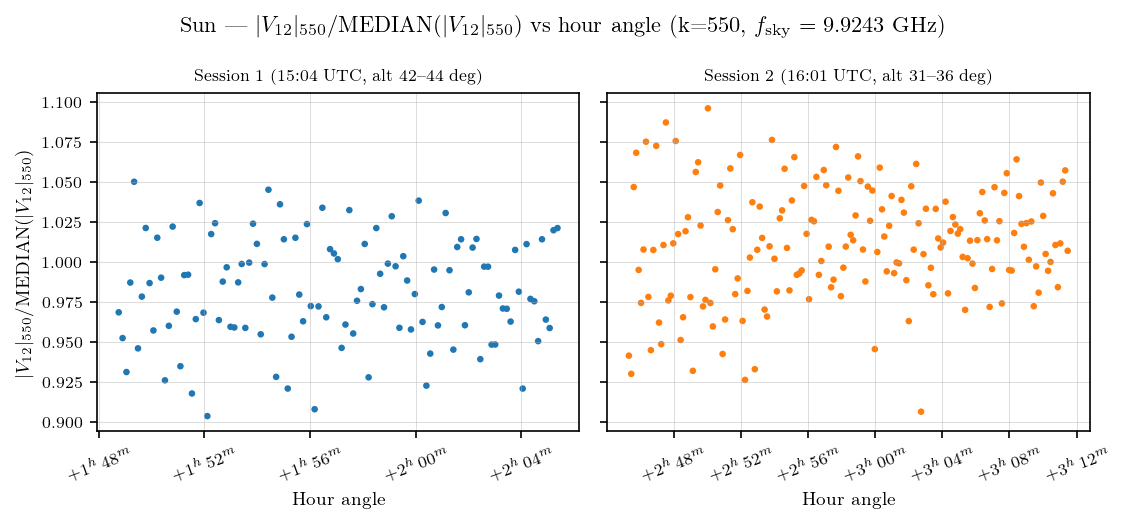

In [4]:
# ---------------------------------------------------------------------------
# |V_12|_550/MEDIAN(|V_12|_550) vs hour angle — channel k=550
# Two panels: Session 1 (left) and Session 2 (right)
# ---------------------------------------------------------------------------

K_PLOT = 550
F_PLOT_GHZ = F_SKY_GHZ[K_PLOT]

# Global median of |V_12| at k=550 across both sessions
AMP_MEDIAN_550 = np.nanmedian(all_amp[:, K_PLOT])
print(f'Median |V_12| at k={K_PLOT}: {AMP_MEDIAN_550:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 3.5),
                          sharey=True, sharex=False)

for ax, sd, label, color in zip(axes, sessions_data, SESSION_LABELS, SESSION_COLORS):
    vis = np.array([f['corr'][K_PLOT] for f in sd['files_s']])
    amp = np.abs(vis) / AMP_MEDIAN_550

    ax.scatter(sd['ha_deg'], amp, s=SCATTER_S_FINE, color=color, edgecolors='none')
    ax.set_title(label, fontsize=TICK_SIZE)
    ax.set_xlabel('Hour angle')
    ax.xaxis.set_major_formatter(HA_FMT)
    ax.tick_params(axis='x', rotation=20)

axes[0].set_ylabel(r'$|V_{12}|_{550} / \mathrm{MEDIAN}(|V_{12}|_{550})$')

fig.suptitle(
    rf'Sun --- $|V_{{12}}|_{{550}} / \mathrm{{MEDIAN}}(|V_{{12}}|_{{550}})$ vs hour angle  '
    rf'(k={K_PLOT}, $f_{{\rm sky}}={F_PLOT_GHZ:.4f}$ GHz)'
)
fig.tight_layout()
plt.show()